In [1]:
# Instalar bibliotecas
!pip install openpyxl --quiet

In [3]:
# Conectar ao Google Drive para acessar o arquivo CSV
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive montado com sucesso!")
print("Navegue até /content/drive/MyDrive para encontrar seus arquivos")

Mounted at /content/drive
Google Drive montado com sucesso!
Navegue até /content/drive/MyDrive para encontrar seus arquivos


In [4]:
# Importar todas as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [8]:
# Caminho do arquivo no Google Drive
caminho_arquivo = '/content/drive/MyDrive/Fase 2 Projeto Em Business Intelligence e Analytics/demandas_historico.csv'

# Detectar separador automaticamente e carregar
try:
    df = pd.read_csv(caminho_arquivo, encoding='utf-8-sig', sep=';')
    print(f"Carregado com separador ponto e vírgula (;)")
except:
    df = pd.read_csv(caminho_arquivo, encoding='utf-8-sig', sep=',')
    print(f"Carregado com separador vírgula (,)")

# Ver as primeiras linhas
print(f"Arquivo carregado com sucesso!")
print(f"Total de demandas: {len(df)}")
print(f"\nColunas encontradas:")
print(df.columns.tolist())
print(f"\nPrimeiras 5 linhas:")
df.head()

Carregado com separador ponto e vírgula (;)
Arquivo carregado com sucesso!
Total de demandas: 125

Colunas encontradas:
['Nome da Demanda', 'Área / Canal', 'Tipo', 'Responsável', 'Prazo Desejado', 'Urgência (1-10)', 'Impacto (1-10)', 'Quadrante', 'Status', 'Criado em', 'Criado por', 'Descrição', 'Observações']

Primeiras 5 linhas:


,Nome da Demanda,Área / Canal,Tipo,Responsável,Prazo Desejado,Urgência (1-10),Impacto (1-10),Quadrante,Status,Criado em,Criado por,Descrição,Observações
0,Processo de cobrança PME inadimplentes,GPME,Regulamento,Nathalia Prestes,27/03/2023,3,2,Backlog,Concluída,07/01/2023,nathalia.prestes@unimedserragaucha.com.br,Demanda de regulamento relacionada a processo ...,NaN
1,Revisão de cláusulas contratuais PME,GPME,Processo,Orlando Fava,28/02/2023,10,5,Critica,Concluída,15/01/2023,orlando.fava@unimedserragaucha.com.br,Demanda de processo relacionada a revisão de c...,NaN
2,Painel de indicadores de mercado mensal,Superintendência de Mercado,Parceiro,Bruno Teixeira,08/06/2023,4,4,Backlog,Concluída,22/02/2023,bruno.teixeira@unimedserragaucha.com.br,Demanda de parceiro relacionada a painel de in...,NaN
3,Revisão de contrato parceria farmácia,Parcerias,Regulamento,Mariana Ghisleni,23/05/2023,10,9,Critica,Concluída,22/02/2023,mariana.ghisleni@unimedserragaucha.com.br,Demanda de regulamento relacionada a revisão d...,NaN
4,Implantação de pesquisa de satisfação pós-aten...,GCC,Treinamento,Karen Oliveira,10/05/2023,8,3,Estrategica,Concluída,23/03/2023,karen.oliveira@unimedserragaucha.com.br,Demanda de treinamento relacionada a implantaç...,NaN


In [34]:
# Cópia dos dados originais
df_original = df.copy()

# 1. Converter datas
df['Criado em'] = pd.to_datetime(df['Criado em'], dayfirst=True, errors='coerce')
df['Prazo Desejado'] = pd.to_datetime(df['Prazo Desejado'], dayfirst=True, errors='coerce')

# 2. Calcular prazo em dias
df['Prazo_em_Dias'] = (df['Prazo Desejado'] - df['Criado em']).dt.days

# 3. Criar colunas de período
df['Mes_Criacao'] = df['Criado em'].dt.month
df['Ano_Criacao'] = df['Criado em'].dt.year
df['MesAno'] = df['Criado em'].dt.to_period('M')

# 4. Padronizar nomes do Quadrante (corrigir acentos perdidos no CSV)
mapa_quadrante = {
    'Critica':     'Crítica',
    'Crítica':     'Crítica',
    'Urgente':     'Urgente',
    'Estrategica': 'Estratégica',
    'Estratégica': 'Estratégica',
    'Backlog':     'Backlog'
}
df['Quadrante'] = df['Quadrante'].map(mapa_quadrante).fillna(df['Quadrante'])

# 5. Criar coluna de risco de atraso
df['Em_Atraso'] = ((df['Prazo_em_Dias'] < 30) & (df['Status'] != 'Concluída')).astype(int)

# 6. Preencher campos vazios
df['Observações'] = df['Observações'].fillna('')
df['Descrição'] = df['Descrição'].fillna('')

# 7. Remover linhas sem nome de demanda
df = df.dropna(subset=['Nome da Demanda'])

print('=== DADOS APÓS LIMPEZA ===')
print(f'Total de demandas: {len(df)}')
print(f'\nQuadrante (corrigido):')
print(df['Quadrante'].value_counts())
print(f'\nStatus:')
print(df['Status'].value_counts())

=== DADOS APÓS LIMPEZA ===
Total de demandas: 125

Quadrante (corrigido):
Quadrante
Crítica        43
Backlog        36
Urgente        30
Estratégica    16
Name: count, dtype: int64

Status:
Status
Concluída       79
Backlog         33
Nova             7
Em andamento     4
Aguardando       2
Name: count, dtype: int64


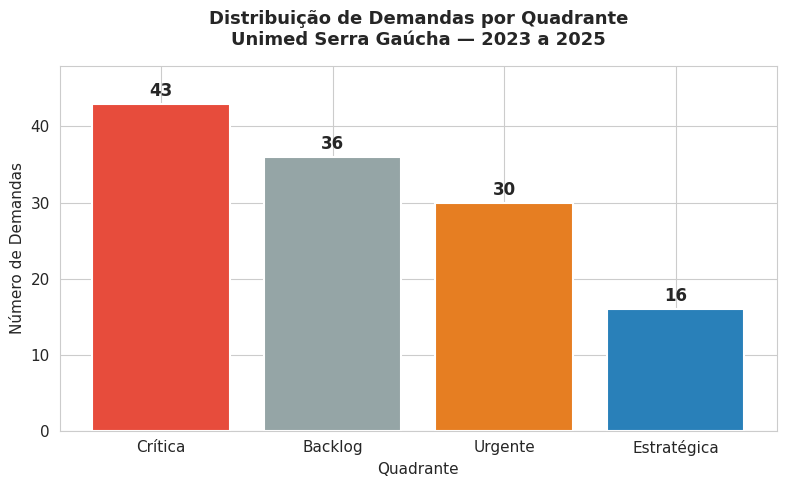

Gráfico salvo como 'grafico_quadrantes.png'


In [35]:
#ANALISE EXPLORATÓRIA

cores_quadrante = {
    'Crítica': '#E74C3C',
    'Urgente': '#E67E22',
    'Estratégica': '#2980B9',
    'Backlog': '#95A5A6'
}

contagem = df['Quadrante'].value_counts()
cores = [cores_quadrante.get(q, '#333333') for q in contagem.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(contagem.index, contagem.values, color=cores, edgecolor='white', linewidth=1.5)

# Adicionar rótulos nas barras
for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Distribuição de Demandas por Quadrante\nUnimed Serra Gaúcha — 2023 a 2025',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Quadrante', fontsize=11)
ax.set_ylabel('Número de Demandas', fontsize=11)
ax.set_ylim(0, contagem.max() + 5)
plt.tight_layout()
plt.savefig('grafico_quadrantes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'grafico_quadrantes.png'")

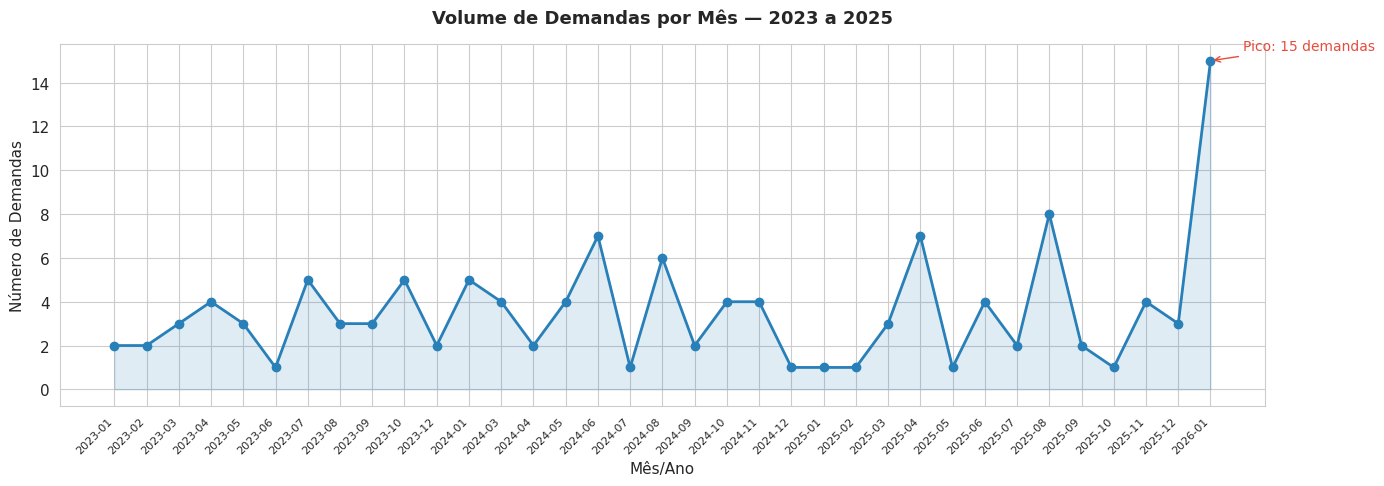

Gráfico salvo como 'grafico_volume_mensal.png'


In [36]:

# ANÁLISE EXPLORATÓRIA — GRÁFICO: Volume de Demandas por Mês

# Agrupar por mês/ano
volume_mensal = df.groupby('MesAno').size().reset_index(name='Total')
volume_mensal['MesAno_str'] = volume_mensal['MesAno'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(volume_mensal['MesAno_str'], volume_mensal['Total'],
        marker='o', color='#2980B9', linewidth=2, markersize=6)
ax.fill_between(range(len(volume_mensal)), volume_mensal['Total'],
                alpha=0.15, color='#2980B9')

# Destacar meses com pico
max_idx = volume_mensal['Total'].idxmax()
ax.annotate(f"Pico: {volume_mensal.loc[max_idx, 'Total']} demandas",
            xy=(max_idx, volume_mensal.loc[max_idx, 'Total']),
            xytext=(max_idx + 1, volume_mensal.loc[max_idx, 'Total'] + 0.5),
            fontsize=10, color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C'))

ax.set_title('Volume de Demandas por Mês — 2023 a 2025', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Mês/Ano', fontsize=11)
ax.set_ylabel('Número de Demandas', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('grafico_volume_mensal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'grafico_volume_mensal.png'")

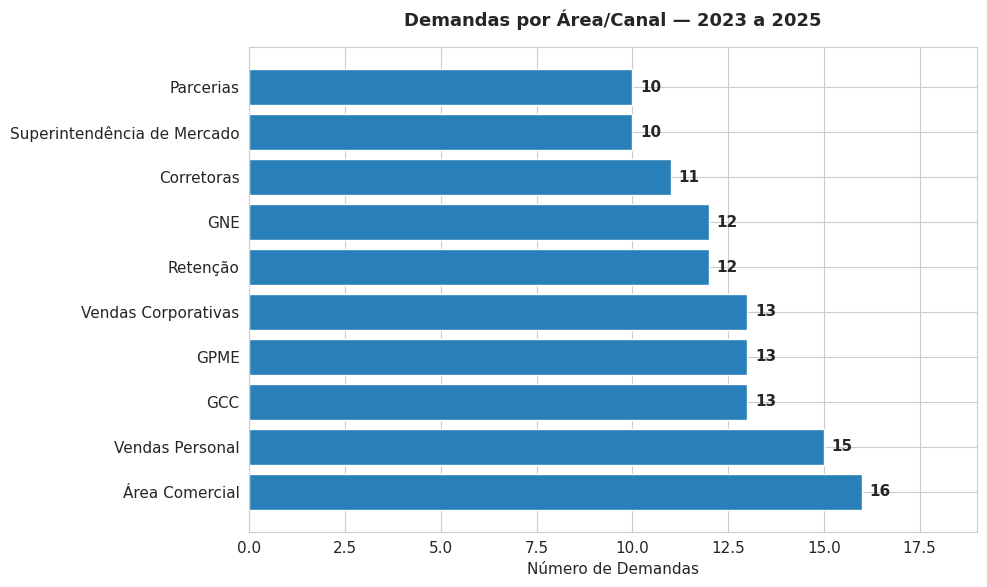

In [37]:

# ANÁLISE EXPLORATÓRIA — GRÁFICO: Demandas por Área/Canal

por_area = df['Área / Canal'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(por_area.index, por_area.values, color='#2980B9', edgecolor='white')

for bar, val in zip(bars, por_area.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')

ax.set_title('Demandas por Área/Canal — 2023 a 2025', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Número de Demandas', fontsize=11)
ax.set_xlim(0, por_area.max() + 3)
plt.tight_layout()
plt.savefig('grafico_por_area.png', dpi=150, bbox_inches='tight')
plt.show()

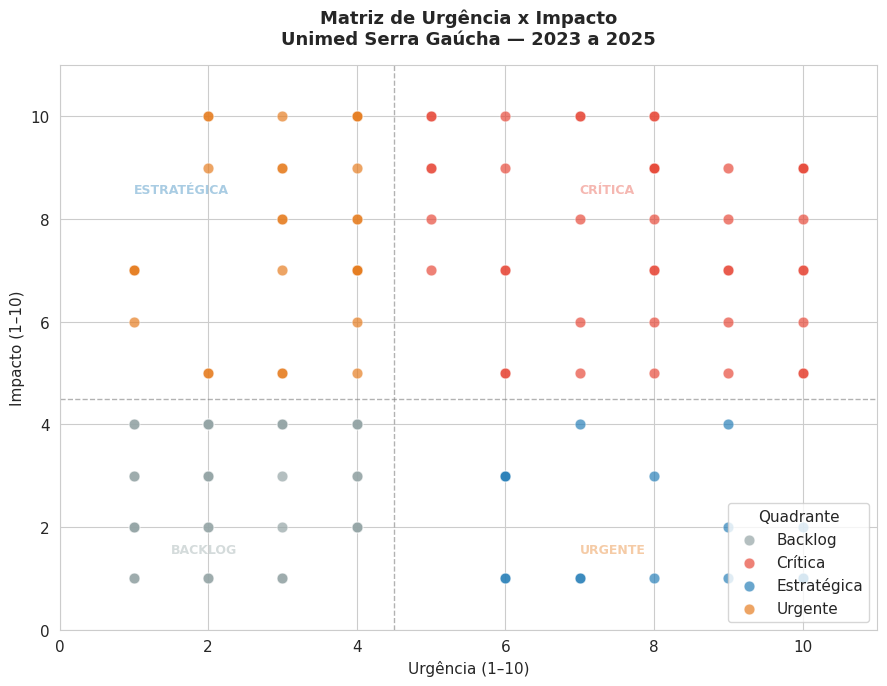

In [38]:

# ANÁLISE EXPLORATÓRIA — GRÁFICO: Matriz Urgência x Impacto

fig, ax = plt.subplots(figsize=(9, 7))

for quadrante, grupo in df.groupby('Quadrante'):
    cor = cores_quadrante.get(quadrante, '#333333')
    ax.scatter(grupo['Urgência (1-10)'], grupo['Impacto (1-10)'],
               label=quadrante, color=cor, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

# Linhas divisórias dos quadrantes
ax.axvline(x=4.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=4.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Labels dos quadrantes no fundo
ax.text(7, 8.5, 'CRÍTICA', fontsize=9, color='#E74C3C', alpha=0.4, fontweight='bold')
ax.text(7, 1.5, 'URGENTE', fontsize=9, color='#E67E22', alpha=0.4, fontweight='bold')
ax.text(1, 8.5, 'ESTRATÉGICA', fontsize=9, color='#2980B9', alpha=0.4, fontweight='bold')
ax.text(1.5, 1.5, 'BACKLOG', fontsize=9, color='#95A5A6', alpha=0.4, fontweight='bold')

ax.set_title('Matriz de Urgência x Impacto\nUnimed Serra Gaúcha — 2023 a 2025',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Urgência (1–10)', fontsize=11)
ax.set_ylabel('Impacto (1–10)', fontsize=11)
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.legend(title='Quadrante', loc='lower right')
plt.tight_layout()
plt.savefig('grafico_matriz_dispersao.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:

# ANÁLISE PREDITIVA — REGRESSÃO LINEAR
# Objetivo: prever o PRAZO EM DIAS de uma demanda com base em
# suas características (urgência, impacto, tipo, área)

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

print("PREPARAÇÃO DOS DADOS PARA O MODELO")

# Selecionar colunas relevantes para o modelo
colunas_modelo = ['Urgência (1-10)', 'Impacto (1-10)', 'Área / Canal', 'Tipo', 'Prazo_em_Dias']
df_modelo = df[colunas_modelo].dropna()

print(f"Demandas com dados completos para o modelo: {len(df_modelo)}")

# Converter variáveis categóricas para numéricas (One-Hot Encoding)
df_modelo_encoded = pd.get_dummies(df_modelo, columns=['Área / Canal', 'Tipo'])

print(f"\nColunas após encoding: {len(df_modelo_encoded.columns)}")
print("Colunas numéricas criadas a partir de categorias:")
colunas_categoricas = [c for c in df_modelo_encoded.columns if 'Área' in c or 'Tipo' in c]
print(colunas_categoricas)

PREPARAÇÃO DOS DADOS PARA O MODELO
Demandas com dados completos para o modelo: 125

Colunas após encoding: 21
Colunas numéricas criadas a partir de categorias:
['Área / Canal_Corretoras', 'Área / Canal_GCC', 'Área / Canal_GNE', 'Área / Canal_GPME', 'Área / Canal_Parcerias', 'Área / Canal_Retenção', 'Área / Canal_Superintendência de Mercado', 'Área / Canal_Vendas Corporativas', 'Área / Canal_Vendas Personal', 'Área / Canal_Área Comercial', 'Tipo_Atendimento', 'Tipo_Outro', 'Tipo_Parceiro', 'Tipo_Processo', 'Tipo_Produto', 'Tipo_Regulamento', 'Tipo_Sistema', 'Tipo_Treinamento']


In [40]:

# TREINAMENTO DO MODELO — REGRESSÃO LINEAR

# Definir variáveis independentes (X) e variável alvo (y)
X = df_modelo_encoded.drop(columns=['Prazo_em_Dias'])
y = df_modelo_encoded['Prazo_em_Dias']

# Dividir em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dados de treino: {len(X_treino)} demandas")
print(f"Dados de teste:  {len(X_teste)} demandas")

# Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Fazer previsões no conjunto de teste
y_previsto = modelo.predict(X_teste)

# Avaliar o modelo
mae = mean_absolute_error(y_teste, y_previsto)
r2 = r2_score(y_teste, y_previsto)

print(f"\nRESULTADO DO MODELO")
print(f"Erro Médio Absoluto (MAE): {mae:.1f} dias")
print(f"R² (coeficiente de determinação): {r2:.3f}")
print(f"\nInterpretação:")
print(f"  → O modelo erra, em média, {mae:.1f} dias na previsão do prazo.")
print(f"  → O R² de {r2:.3f} indica que o modelo explica {r2*100:.1f}% da variação dos prazos.")

Dados de treino: 100 demandas
Dados de teste:  25 demandas

RESULTADO DO MODELO
Erro Médio Absoluto (MAE): 27.7 dias
R² (coeficiente de determinação): -0.398

Interpretação:
  → O modelo erra, em média, 27.7 dias na previsão do prazo.
  → O R² de -0.398 indica que o modelo explica -39.8% da variação dos prazos.


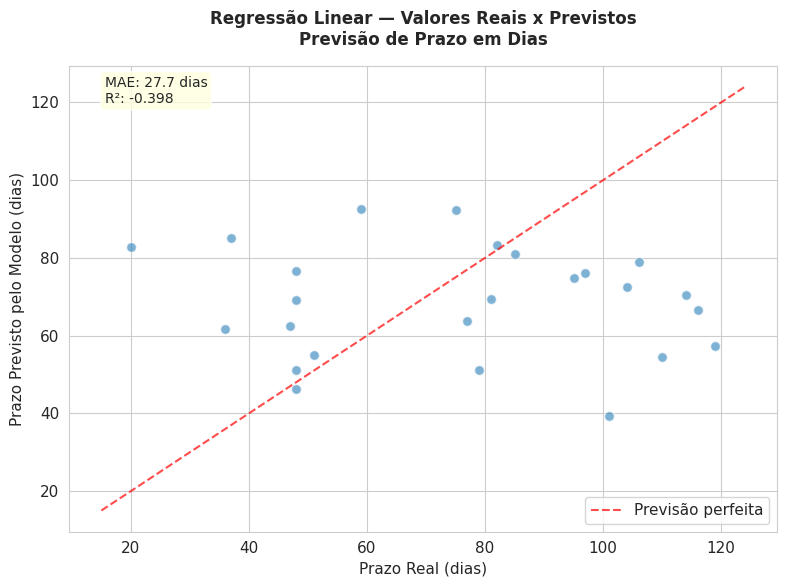

In [41]:

# GRÁFICO: Valores Reais x Previstos pelo Modelo

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_teste, y_previsto, color='#2980B9', alpha=0.6, s=50, edgecolors='white')

# Linha de referência perfeita (se o modelo acertasse tudo)
lim_min = min(y_teste.min(), y_previsto.min()) - 5
lim_max = max(y_teste.max(), y_previsto.max()) + 5
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        'r--', linewidth=1.5, label='Previsão perfeita', alpha=0.7)

ax.set_title('Regressão Linear — Valores Reais x Previstos\nPrevisão de Prazo em Dias',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Prazo Real (dias)', fontsize=11)
ax.set_ylabel('Prazo Previsto pelo Modelo (dias)', fontsize=11)
ax.legend()
ax.text(0.05, 0.92, f'MAE: {mae:.1f} dias\nR²: {r2:.3f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('grafico_modelo_preditivo.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:

# INFERÊNCIA — Prever o prazo de uma nova demanda

print("TESTE DE INFERÊNCIA")
print("Vamos prever o prazo de uma demanda nova que ainda não existe na base.\n")

# Criar uma demanda fictícia para testar o modelo
nova_demanda = {
    'Urgência (1-10)': 8,
    'Impacto (1-10)': 7,
    'Área/Canal': 'Retenção',
    'Tipo': 'Processo'
}

print(f"Nova demanda:")
print(f"  Urgência: {nova_demanda['Urgência (1-10)']}")
print(f"  Impacto:  {nova_demanda['Impacto (1-10)']}")
print(f"  Área:     {nova_demanda['Área/Canal']}")
print(f"  Tipo:     {nova_demanda['Tipo']}")

# Criar DataFrame com a nova demanda no mesmo formato do treino
nova_df = pd.DataFrame([nova_demanda])
nova_encoded = pd.get_dummies(nova_df, columns=['Área/Canal', 'Tipo'])

# Alinhar colunas com o modelo treinado
nova_aligned = nova_encoded.reindex(columns=X.columns, fill_value=0)

# Fazer a previsão
prazo_previsto = modelo.predict(nova_aligned)[0]

print(f"\nPrevisão do modelo:")
print(f"  Prazo estimado: {prazo_previsto:.0f} dias")

if prazo_previsto < 30:
    print(f"  Atenção: prazo curto — demanda com risco de atraso!")
elif prazo_previsto < 60:
    print(f"  Prazo moderado — monitorar andamento.")
else:
    print(f"  Prazo adequado para planejamento.")

TESTE DE INFERÊNCIA
Vamos prever o prazo de uma demanda nova que ainda não existe na base.

Nova demanda:
  Urgência: 8
  Impacto:  7
  Área:     Retenção
  Tipo:     Processo

Previsão do modelo:
  Prazo estimado: 82 dias
  Prazo adequado para planejamento.


In [43]:

# EXPORTAR CSV PROCESSADO PARA USO NO POWER BI

df_exportar = df[['Nome da Demanda', 'Área / Canal', 'Tipo', 'Responsável',
                   'Prazo Desejado', 'Urgência (1-10)', 'Impacto (1-10)',
                   'Quadrante', 'Status', 'Criado em', 'Prazo_em_Dias',
                   'Mes_Criacao', 'Ano_Criacao', 'Em_Atraso']].copy()

# Formatar datas
df_exportar['Criado em'] = pd.to_datetime(df['Criado em'], dayfirst=True).dt.strftime('%d/%m/%Y')
df_exportar['Prazo Desejado'] = pd.to_datetime(df['Prazo Desejado'], dayfirst=True).dt.strftime('%d/%m/%Y')

# Adicionar ID sequencial
df_exportar.insert(0, 'ID', range(1, len(df_exportar) + 1))

# Salvar no Drive
caminho_saida = '/content/drive/MyDrive/Fase 2 Projeto Em Business Intelligence e Analytics/demandas_processadas.csv'
df_exportar.to_csv(caminho_saida, index=False, encoding='utf-8-sig', sep=';')

print(f'Arquivo exportado com sucesso!')
print(f'Caminho: {caminho_saida}')
print(f'Total de registros: {len(df_exportar)}')
print(f'\nColunas exportadas:')
print(df_exportar.columns.tolist())
print(f'\nPrimeiras 3 linhas:')
print(df_exportar.head(3).to_string())

Arquivo exportado com sucesso!
Caminho: /content/drive/MyDrive/Fase 2 Projeto Em Business Intelligence e Analytics/demandas_processadas.csv
Total de registros: 125

Colunas exportadas:
['ID', 'Nome da Demanda', 'Área / Canal', 'Tipo', 'Responsável', 'Prazo Desejado', 'Urgência (1-10)', 'Impacto (1-10)', 'Quadrante', 'Status', 'Criado em', 'Prazo_em_Dias', 'Mes_Criacao', 'Ano_Criacao', 'Em_Atraso']

Primeiras 3 linhas:
   ID                          Nome da Demanda                 Área / Canal         Tipo       Responsável Prazo Desejado  Urgência (1-10)  Impacto (1-10) Quadrante     Status   Criado em  Prazo_em_Dias  Mes_Criacao  Ano_Criacao  Em_Atraso
0   1   Processo de cobrança PME inadimplentes                         GPME  Regulamento  Nathalia Prestes     27/03/2023                3               2   Backlog  Concluída  07/01/2023             79            1         2023          0
1   2     Revisão de cláusulas contratuais PME                         GPME     Processo      Orla

In [44]:

# RESUMO FINAL
print("RESUMO DA ANÁLISE — UNIMED SERRA GAÚCHA")


total = len(df)
criticas = len(df[df['Quadrante'] == 'Crítica'])
atrasadas = df['Em_Atraso'].sum()

print(f"\nTotal de demandas analisadas: {total}")
print(f"Demandas Críticas:            {criticas} ({criticas/total*100:.1f}%)")
print(f"Demandas em risco de atraso:  {atrasadas} ({atrasadas/total*100:.1f}%)")
print(f"\nModelo preditivo treinado:")
print(f"   Algoritmo: Regressão Linear")
print(f"   Erro médio (MAE): {mae:.1f} dias")
print(f"   R²: {r2:.3f}")
print(f"\nArquivos gerados:")
print(f"   - grafico_quadrantes.png")
print(f"   - grafico_volume_mensal.png")
print(f"   - grafico_por_area.png")
print(f"   - grafico_matriz_dispersao.png")
print(f"   - grafico_modelo_preditivo.png")
print(f"   - demandas_processadas.csv (para Power BI)")


RESUMO DA ANÁLISE — UNIMED SERRA GAÚCHA

Total de demandas analisadas: 125
Demandas Críticas:            43 (34.4%)
Demandas em risco de atraso:  3 (2.4%)

Modelo preditivo treinado:
   Algoritmo: Regressão Linear
   Erro médio (MAE): 27.7 dias
   R²: -0.398

Arquivos gerados:
   - grafico_quadrantes.png
   - grafico_volume_mensal.png
   - grafico_por_area.png
   - grafico_matriz_dispersao.png
   - grafico_modelo_preditivo.png
   - demandas_processadas.csv (para Power BI)
